# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Yunita Asri Prameswari]
- **Email:** [cdcc200d6x2238@student.devacademy.id]
- **ID Dicoding:** [CDCC200D6X2238]

## Menentukan Pertanyaan Bisnis

- Apakah terjadi kenaikan signifikan pada total peminjaman sepeda dari tahun 2011 ke 2012, bulan apa yang umumnya menjadi titik puncak dan titik terendah peminjaman?
- Pada jam berapa dan hari apa terjadi peminjaman sepeda paling tinggi, dan apakah pola ini berbeda antara pengguna kasual (casual) dengan pengguna terdaftar (registered)?
- Seberapa besar pengaruh kondisi cuaca (suhu, kelembaban, kecepatan angin, situasi cuaca) dan musim terhadap jumlah peminjaman sepeda harian?
- Apakah terdapat perbedaan yang signifikan dalam pola peminjaman sepeda antara hari kerja, hari libur nasional, dan akhir pekan, dan bagaimana perbedaan tersebut dilihat dari segmen kasual vs. terdaftar?
- Bagaimana proporsi pengguna kasual vs. terdaftar berubah sepanjang musim dan kondisi cuaca, dan faktor apa yang paling membedakan perilaku kedua segmen ini?

## Import Semua Packages/Library yang Digunakan

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load dataframe

In [28]:
# Load dataset
df_day  = pd.read_csv('D:\College\Dicoding\SubmissionAnalisisData-CC26\data\day.csv')
df_hour = pd.read_csv('D:\College\Dicoding\SubmissionAnalisisData-CC26\data\hour.csv')

print(f'day.csv  → {df_day.shape[0]:,} baris × {df_day.shape[1]} kolom')
print(f'hour.csv → {df_hour.shape[0]:,} baris × {df_hour.shape[1]} kolom')

day.csv  → 731 baris × 16 kolom
hour.csv → 17,379 baris × 17 kolom


<>:2: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<>:3: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<>:2: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<>:3: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
C:\Users\ADVAN WORKPRO\AppData\Local\Temp\ipykernel_9636\1261875011.py:2: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
  df_day  = pd.read_csv('D:\College\Dicoding\SubmissionAnalisisData-CC26\data\day.csv')
C:\Users\ADVAN WORKPRO\AppData\Local\Temp\ipykernel_9636\1261875011.py:3: Synta

In [29]:
# Inspeksi awal day.csv
display(df_day.head())

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [30]:
# Inspeksi awal hour.csv
display(df_hour.head())

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [31]:
# Rentang tanggal & distribusi per tahun
print(f'Rentang day.csv  : {df_day["dteday"].min()} → {df_day["dteday"].max()}')
print(f'Rentang hour.csv : {df_hour["dteday"].min()} → {df_hour["dteday"].max()}')

print(f'\nHari unik day.csv  : {df_day["dteday"].nunique()}')
print(f'Hari unik hour.csv : {df_hour["dteday"].nunique()}')

print('\nDistribusi per tahun:')
print(df_day['yr'].value_counts().rename({0: '2011', 1: '2012'}).sort_index())

Rentang day.csv  : 2011-01-01 → 2012-12-31
Rentang hour.csv : 2011-01-01 → 2012-12-31

Hari unik day.csv  : 731
Hari unik hour.csv : 731

Distribusi per tahun:
yr
2011    365
2012    366
Name: count, dtype: int64


**Insight:**
- data day.csv : menunjukkan jumlah peminjaman sepeda yang dihitung per hari.
- data hour.csv : menunjukkan jumlah peminjaman sepeda yang dihitung per jam.
- Kedua dataset mencakup 2 tahun periode pengamatan yang sama mulai 1 Januari 2011 – 31 Desember 2012.
- hour.csv memiliki 24× lebih banyak baris sesuai jumlah jam dalam satu hari. - Seluruh variabel cuaca sudah dalam bentuk ternormalisasi.

### Assessing Data

#### Identifying the problems

In [32]:
# Informasi day.csv
print(df_day.info())

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 91.5 KB
None


In [33]:
# Informasi hour.csv
df_hour.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


Dari output di atas terlihat bahwa tidak ada masalah dengan tipe data, dilihat dari jumlah non null juga menunjukkan tidak adanya missing value, namun akan tetap dilakukan pengecekan.

In [34]:
# Cek missing value

for name, df in [('day.csv', df_day), ('hour.csv', df_hour)]:
    missing = df.isnull().sum()
    print(f'=== Missing Values — {name} ===')
    if missing.sum() == 0:
        print('✅ Tidak ada missing values.\n')
    else:
        pct = (missing / len(df) * 100).round(2)
        print(pd.DataFrame({'Missing': missing, '%': pct})[missing > 0], '\n')

=== Missing Values — day.csv ===
✅ Tidak ada missing values.

=== Missing Values — hour.csv ===
✅ Tidak ada missing values.



In [35]:
# Cek duplikasi

for name, df in [('day.csv', df_day), ('hour.csv', df_hour)]:
    print(f'Duplikat data di {name} : {df.duplicated().sum()}')

print(f'Duplikasi tanggal di day.csv : {df_day["dteday"].duplicated().sum()}')

Duplikat data di day.csv : 0
Duplikat data di hour.csv : 0
Duplikasi tanggal di day.csv : 0


Tidak ada duplikasi data di kedua tabel. Untuk day.csv tidak ada duplikasi tanggal, artinya setiap baris data mewakili hari yang berbeda-beda.

In [36]:
# Tipe data
print('Tipe Data day.csv')
print(df_day.dtypes)
print('\nTipe Data hour.csv')
print(df_hour.dtypes)

Tipe Data day.csv
instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

Tipe Data hour.csv
instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


In [37]:
# Validasi nilai kategorik
expected = {
    'season'    : {1, 2, 3, 4},
    'yr'        : {0, 1},
    'mnth'      : set(range(1, 13)),
    'hr'        : set(range(0, 24)),
    'holiday'   : {0, 1},
    'weekday'   : set(range(0, 7)),
    'workingday': {0, 1},
    'weathersit': {1, 2, 3, 4}
}

for name, df, cols in [
    ('day.csv',  df_day,  ['season','yr','mnth','holiday','weekday','workingday','weathersit']),
    ('hour.csv', df_hour, ['season','yr','mnth','hr','holiday','weekday','workingday','weathersit'])
]:
    print(f'=== Validasi Kategorik — {name} ===')
    for col in cols:
        actual  = set(df[col].unique())
        invalid = actual - expected[col]
        status  = '✅ Valid' if not invalid else f'⚠️  Nilai tidak valid: {invalid}'
        print(f'  {col:12s} | {status}')
    print()

=== Validasi Kategorik — day.csv ===
  season       | ✅ Valid
  yr           | ✅ Valid
  mnth         | ✅ Valid
  holiday      | ✅ Valid
  weekday      | ✅ Valid
  workingday   | ✅ Valid
  weathersit   | ✅ Valid

=== Validasi Kategorik — hour.csv ===
  season       | ✅ Valid
  yr           | ✅ Valid
  mnth         | ✅ Valid
  hr           | ✅ Valid
  holiday      | ✅ Valid
  weekday      | ✅ Valid
  workingday   | ✅ Valid
  weathersit   | ✅ Valid



In [38]:
df_day.describe(include='all')

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2011-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,NaN,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,NaN,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,NaN,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,NaN,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000


In [39]:
df_hour.describe(include='all')

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2011-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,NaN,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,NaN,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,NaN,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,NaN,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000


In [40]:
# Cek konsistensi antar kolom

# casual + registered == cnt
for name, df in [('day.csv', df_day), ('hour.csv', df_hour)]:
    mismatch = df[df['casual'] + df['registered'] != df['cnt']]
    status   = '✅ Konsisten' if len(mismatch) == 0 else f'⚠️  {len(mismatch)} baris tidak konsisten'
    print(f'casual+registered == cnt di {name} : {status}')

# Waktu pengamatan per hari di hour.csv
hours_per_day = df_hour.groupby('dteday', observed=True)['hr'].count()
anomaly       = hours_per_day[hours_per_day != 24]
print(f'\nTanggal dengan record ≠ 24 jam : {len(anomaly)}')
if len(anomaly) == 0:
    print('✅ Semua tanggal memiliki tepat 24 record.')

casual+registered == cnt di day.csv : ✅ Konsisten
casual+registered == cnt di hour.csv : ✅ Konsisten

Tanggal dengan record ≠ 24 jam : 76


**Insight:**
- tidak terdapat missing value dan duplicated data pada data day.csv dan hour.csv
- kolom dteday masih dalam tipe object, sehingga perlu diubah ke datetime
- nilai minimum humidity (hum) = 0 yang mana hampir tidak mungkin terjadi dalam kondisi normal, sehingga kemungkinan terjadi error pada sensor atau saat entry data
- Terdapat beberapa tanggal yang waktu pengamatannya tidak sama dengan 24 jam, artinya ada beberapa waktu yang tidak terdapat aktifitas peminjaman

**Step to Take:**
- kolom dteday masih dalam tipe object, sehingga perlu diubah ke datetime.
- perlu menambahkan label deskriptif pada kolom kategorik untuk mempermudah interpretasi
- hum == 0 perlu dideteksi dan dilakukan perubahan nilai dengan imputasi nilai median

### Cleaning Data

#### Fixing the Problem

In [41]:
# Konversi dteday ke datetime
df_day['dteday']  = pd.to_datetime(df_day['dteday'])
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])

print('Tipe dteday df_day  :', df_day['dteday'].dtype)
print('Tipe dteday df_hour :', df_hour['dteday'].dtype)

Tipe dteday df_day  : datetime64[us]
Tipe dteday df_hour : datetime64[us]


In [42]:
# Konversi kolom kategorik + label deskriptif
season_map     = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
yr_map         = {0: '2011', 1: '2012'}
weekday_map    = {0: 'Sunday', 1: 'Monday', 2: 'Tuesday',
                  3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday'}
weathersit_map = {1: 'Clear', 2: 'Mist/Cloudy',
                  3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow'}
binary_map     = {0: 'No', 1: 'Yes'}

for df in [df_day, df_hour]:
    df['season']     = df['season'].map(season_map).astype('category')
    df['yr']         = df['yr'].map(yr_map).astype('category')
    df['weekday']    = df['weekday'].map(weekday_map).astype('category')
    df['weathersit'] = df['weathersit'].map(weathersit_map).astype('category')
    df['holiday']    = df['holiday'].map(binary_map).astype('category')
    df['workingday'] = df['workingday'].map(binary_map).astype('category')
    df['mnth']       = df['mnth'].astype('category')

# Tetapkan urutan ordinal
season_order     = ['Spring', 'Summer', 'Fall', 'Winter']
weekday_order    = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
weathersit_order = ['Clear', 'Mist/Cloudy', 'Light Rain/Snow', 'Heavy Rain/Snow']

for df in [df_day, df_hour]:
    df['season']     = pd.Categorical(df['season'],     categories=season_order,     ordered=True)
    df['weekday']    = pd.Categorical(df['weekday'],    categories=weekday_order,    ordered=True)
    df['weathersit'] = pd.Categorical(df['weathersit'], categories=weathersit_order, ordered=True)

print('✅ Konversi kategori selesai.')

✅ Konversi kategori selesai.


In [43]:
# Identifikasi dan imputasi hum
idx_hum_zero = df_day[df_day['hum'] == 0].index

for idx in idx_hum_zero:
    season_val = df_day.loc[idx, 'season']
    mnth_val   = df_day.loc[idx, 'mnth']

    median_hum = df_day[
        (df_day['season'] == season_val) &
        (df_day['mnth']   == mnth_val)   &
        (df_day['hum']    > 0)
    ]['hum'].median()

    df_day.loc[idx, 'hum'] = median_hum
    print(f'✅ Baris {idx}: hum → {median_hum:.4f} (median season={season_val}, mnth={mnth_val})')

print(f'Sisa hum==0: {(df_day["hum"] == 0).sum()}')

✅ Baris 68: hum → 0.5675 (median season=Spring, mnth=3)
Sisa hum==0: 0


In [44]:
# Drop kolom yang tidak relevan
df_day.drop(columns=['instant'], inplace=True)
df_hour.drop(columns=['instant'], inplace=True)

print('✅ Kolom instant dihapus.')

✅ Kolom instant dihapus.


In [45]:
# Cek fixing problems steps
for name, df in [('day', df_day), ('hour', df_hour)]:
    print(f'=== {name} ===')
    print(f'Shape          : {df.shape}')
    print(f'Missing values : {df.isnull().sum().sum()}')
    print(f'Duplikasi      : {df.duplicated().sum()}')
    print(f'Tipe dteday    : {df["dteday"].dtype}\n')

=== day ===
Shape          : (731, 15)
Missing values : 0
Duplikasi      : 0
Tipe dteday    : datetime64[us]

=== hour ===
Shape          : (17379, 16)
Missing values : 0
Duplikasi      : 0
Tipe dteday    : datetime64[us]



Setelah dilakukan step-step penanganan, data yang digunakan sudah bebas dari missing value dan duplicate, tipe datanya juga sudah sesuai maka bisa dilanjutkan ke tahap ekplorasi data.

## Exploratory Data Analysis (EDA)

### Statistik Deskriptif

In [46]:
print('Statistik Deskriptif day.csv')
display(df_day.describe())

print('\nStatistik Deskriptif hour.csv')
display(df_hour.describe())

Statistik Deskriptif day.csv


,dteday,temp,atemp,hum,windspeed,casual,registered,cnt
count,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,2012-01-01 00:00:00,0.495385,0.474354,0.628670,0.190486,848.176471,3656.172367,4504.348837
min,2011-01-01 00:00:00,0.059130,0.079070,0.187917,0.022392,2.000000,20.000000,22.000000
25%,2011-07-02 12:00:00,0.337083,0.337842,0.521041,0.134950,315.500000,2497.000000,3152.000000
50%,2012-01-01 00:00:00,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,2012-07-01 12:00:00,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,2012-12-31 00:00:00,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,NaN,0.183051,0.162961,0.140536,0.077498,686.622488,1560.256377,1937.211452



Statistik Deskriptif hour.csv


,dteday,hr,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,2012-01-02 04:08:34.552045,11.546752,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,2011-01-01 00:00:00,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-04 00:00:00,6.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,2012-01-02 00:00:00,12.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,2012-07-02 00:00:00,18.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,2012-12-31 00:00:00,23.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,NaN,6.914405,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


### Distribusi Variabel

In [47]:
for name, df in [('day.csv', df_day), ('hour.csv', df_hour)]:
    print(f'=== Distribusi cnt ({name}) ===')
    print(f'Mean   : {df["cnt"].mean():.1f}')
    print(f'Median : {df["cnt"].median():.1f}')
    print(f'Std    : {df["cnt"].std():.1f}')
    print(f'Min    : {df["cnt"].min()}')
    print(f'Max    : {df["cnt"].max()}\n')

=== Distribusi cnt (day.csv) ===
Mean   : 4504.3
Median : 4548.0
Std    : 1937.2
Min    : 22
Max    : 8714

=== Distribusi cnt (hour.csv) ===
Mean   : 189.5
Median : 142.0
Std    : 181.4
Min    : 1
Max    : 977



**Insight:**
- Rata-rata peminjaman harian adalah sekitar 4.504 kali dengan standar deviasi 1.937, menunjukkan variasi yang cukup besar antar hari. Nilai minimum 22 dan maksimum 8.714 mengindikasikan bahwa ada hari-hari dengan aktivitas sangat rendah (kemungkinan cuaca ekstrem atau hari libur tertentu) dan hari-hari dengan permintaan sangat tinggi.
- Distribusi peminjaman harian cenderung mendekati normal dengan sedikit skew ke kanan, artinya sebagian besar hari berada di kisaran peminjaman menengah namun ada beberapa hari dengan peminjaman sangat tinggi yang menarik rata-rata ke atas.

### Tren Peminjaman Sepeda

In [48]:
yearly = df_day.groupby('yr', observed=True)['cnt'].agg(['sum', 'mean']).reset_index()
yearly.columns = ['yr', 'total', 'rata_rata']
yearly['growth_pct'] = yearly['total'].pct_change() * 100
display(yearly)

,yr,total,rata_rata,growth_pct
0,2011,1243103,3405.761644,NaN
1,2012,2049576,5599.934426,64.875799


In [49]:
monthly = df_day.groupby(['mnth', 'yr'], observed=True)['cnt'].mean().reset_index()
monthly = monthly.pivot(index='mnth', columns='yr', values='cnt')
monthly.index = monthly.index.astype(int)
monthly = monthly.sort_index()
monthly.columns.name = None
monthly['rata_rata'] = monthly.mean(axis=1).round(1)
display(monthly)

print(f"Bulan tertinggi : bulan {monthly['rata_rata'].idxmax()} ({monthly['rata_rata'].max():.1f})")
print(f"Bulan terendah  : bulan {monthly['rata_rata'].idxmin()} ({monthly['rata_rata'].min():.1f})")

,2011,2012,rata_rata
mnth,,,
1,1231.903226,3120.774194,2176.3
2,1721.964286,3556.448276,2639.2
3,2065.967742,5318.548387,3692.3
4,3162.333333,5807.466667,4484.9
5,4381.322581,6318.225806,5349.8
6,4783.733333,6761.000000,5772.4
7,4559.387097,6567.967742,5563.7
8,4409.387097,6919.451613,5664.4
9,4247.266667,7285.766667,5766.5


Bulan tertinggi : bulan 6 (5772.4)
Bulan terendah  : bulan 1 (2176.3)


### Pola Peminjaman per Jam dan Hari

In [50]:
hourly = df_hour.groupby('hr', observed=True)['cnt'].mean().reset_index()
hourly.columns = ['hr', 'rata_rata']
display(hourly)

print(f"Jam tersibuk  : jam {hourly.loc[hourly['rata_rata'].idxmax(), 'hr']} ({hourly['rata_rata'].max():.1f})")
print(f"Jam tersenyap : jam {hourly.loc[hourly['rata_rata'].idxmin(), 'hr']} ({hourly['rata_rata'].min():.1f})")

,hr,rata_rata
0,0,53.898072
1,1,33.375691
2,2,22.869930
3,3,11.727403
4,4,6.352941
5,5,19.889819
6,6,76.044138
7,7,212.064649
8,8,359.011004
9,9,219.309491


Jam tersibuk  : jam 17 (461.5)
Jam tersenyap : jam 4 (6.4)


In [51]:
hourly_seg = df_hour.groupby('hr', observed=True)[['casual', 'registered']].mean().reset_index()
display(hourly_seg)

,hr,casual,registered
0,0,10.158402,43.739669
1,1,6.504144,26.871547
2,2,4.772028,18.097902
3,3,2.715925,9.011478
4,4,1.253945,5.098996
5,5,1.411437,18.478382
6,6,4.161379,71.882759
7,7,11.055021,201.009629
8,8,21.679505,337.331499
9,9,30.891334,188.418157


In [52]:
weekday_avg = df_day.groupby('weekday', observed=True)[['casual', 'registered', 'cnt']].mean().reset_index()
display(weekday_avg)

,weekday,casual,registered,cnt
0,Sunday,1338.295238,2890.533333,4228.828571
1,Monday,674.133333,3663.990476,4338.123810
2,Tuesday,556.182692,3954.480769,4510.663462
3,Wednesday,551.144231,3997.394231,4548.538462
4,Thursday,590.961538,4076.298077,4667.259615
5,Friday,752.288462,3938.000000,4690.288462
6,Saturday,1465.257143,3085.285714,4550.542857


### Pengaruh Musim dan Cuaca

In [53]:
season_avg = df_day.groupby('season', observed=True)[['casual', 'registered', 'cnt']].mean().reset_index()
display(season_avg)

,season,casual,registered,cnt
0,Spring,334.928177,2269.204420,2604.132597
1,Summer,1106.097826,3886.233696,4992.331522
2,Fall,1202.611702,4441.691489,5644.303191
3,Winter,729.112360,3999.050562,4728.162921


In [54]:
weather_avg = df_day.groupby('weathersit', observed=True)[['casual', 'registered', 'cnt']].mean().reset_index()
display(weather_avg)

,weathersit,casual,registered,cnt
0,Clear,964.030238,3912.755940,4876.786177
1,Mist/Cloudy,687.352227,3348.510121,4035.862348
2,Light Rain/Snow,185.476190,1617.809524,1803.285714


In [55]:
num_cols = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']
corr = df_day[num_cols].corr()[['cnt']].drop('cnt')
display(corr.sort_values('cnt', ascending=False))

,cnt
atemp,0.631066
temp,0.627494
hum,-0.113098
windspeed,-0.234545


### Pola Hari Kerja dan Hari Libur

In [56]:
workday_avg = df_day.groupby('workingday', observed=True)[['casual', 'registered', 'cnt']].mean().reset_index()
display(workday_avg)

holiday_avg = df_day.groupby('holiday', observed=True)[['casual', 'registered', 'cnt']].mean().reset_index()
display(holiday_avg)

,workingday,casual,registered,cnt
0,No,1371.134199,2959.034632,4330.168831
1,Yes,606.570000,3978.250000,4584.820000


,holiday,casual,registered,cnt
0,No,841.771831,3685.332394,4527.104225
1,Yes,1064.714286,2670.285714,3735.000000


### Perbandingan Pengguna Casual dan Registered

In [57]:
total_casual     = df_day['casual'].sum()
total_registered = df_day['registered'].sum()
total_cnt        = df_day['cnt'].sum()

print(f'Casual     : {total_casual:,} ({total_casual / total_cnt * 100:.1f}%)')
print(f'Registered : {total_registered:,} ({total_registered / total_cnt * 100:.1f}%)')

Casual     : 620,017 (18.8%)
Registered : 2,672,662 (81.2%)


In [58]:
seg_season = df_day.groupby('season', observed=True)[['casual', 'registered']].mean().reset_index()
seg_season['total']          = seg_season['casual'] + seg_season['registered']
seg_season['pct_casual']     = (seg_season['casual']     / seg_season['total'] * 100).round(1)
seg_season['pct_registered'] = (seg_season['registered'] / seg_season['total'] * 100).round(1)
display(seg_season)

,season,casual,registered,total,pct_casual,pct_registered
0,Spring,334.928177,2269.204420,2604.132597,12.9,87.1
1,Summer,1106.097826,3886.233696,4992.331522,22.2,77.8
2,Fall,1202.611702,4441.691489,5644.303191,21.3,78.7
3,Winter,729.112360,3999.050562,4728.162921,15.4,84.6


In [59]:
seg_weather = df_day.groupby('weathersit', observed=True)[['casual', 'registered']].mean().reset_index()
seg_weather['total']          = seg_weather['casual'] + seg_weather['registered']
seg_weather['pct_casual']     = (seg_weather['casual']     / seg_weather['total'] * 100).round(1)
seg_weather['pct_registered'] = (seg_weather['registered'] / seg_weather['total'] * 100).round(1)
display(seg_weather)

,weathersit,casual,registered,total,pct_casual,pct_registered
0,Clear,964.030238,3912.755940,4876.786177,19.8,80.2
1,Mist/Cloudy,687.352227,3348.510121,4035.862348,17.0,83.0
2,Light Rain/Snow,185.476190,1617.809524,1803.285714,10.3,89.7


**Insight:**
- Total peminjaman tumbuh signifikan dari 2011 ke 2012. Pola bulanan menunjukkan peminjaman tertinggi terjadi di bulan Juni–September dan terendah di Januari–Februari, konsisten di kedua tahun.
- Jam tersibuk adalah jam 17–18 sore, diikuti jam 8 pagi. Jam tersenyap adalah dini hari (jam 3–4). Pengguna registered rata-rata jauh lebih banyak dari casual di hampir semua jam. Peminjaman per hari dalam seminggu relatif merata, namun komposisi casual vs registered berbeda signifikan antara hari kerja dan weekend.
- Fall (musim gugur) memiliki rata-rata peminjaman tertinggi, diikuti Summer (musim panas). Spring memiliki rata-rata terendah meski musim semi identik dengan cuaca yang membaik, hal ini kemungkinan karena transisi cuaca yang masih tidak menentu. Suhu memiliki korelasi positif terkuat dengan peminjaman, sementara kelembaban dan kecepatan angin berkorelasi negatif.
- Rata-rata peminjaman di hari kerja dan bukan hari kerja relatif setara secara total, namun komposisi penggunanya berbeda. Hari libur nasional cenderung memiliki peminjaman lebih rendah dibanding hari kerja biasa maupun weekend.
- Pengguna registered mendominasi sekitar 80% total peminjaman. Proporsi casual meningkat di musim panas dan cuaca cerah, sementara registered relatif stabil di semua kondisi. Ini mengindikasikan motivasi yang berbeda antara kedua segmen.


## Visualization & Explanatory Analysis

### Pertanyaan 1: Tren

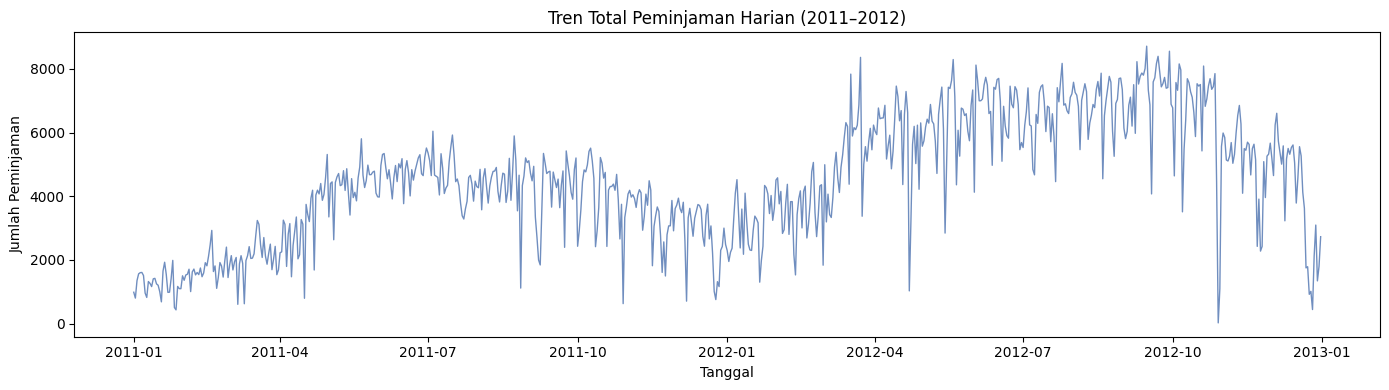

In [60]:
# Tren harian
plt.figure(figsize=(14, 4))
plt.plot(df_day['dteday'], df_day['cnt'], color='#4C72B0', linewidth=1, alpha=0.8)
plt.title('Tren Total Peminjaman Harian (2011–2012)')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Peminjaman')
plt.tight_layout()
plt.show()

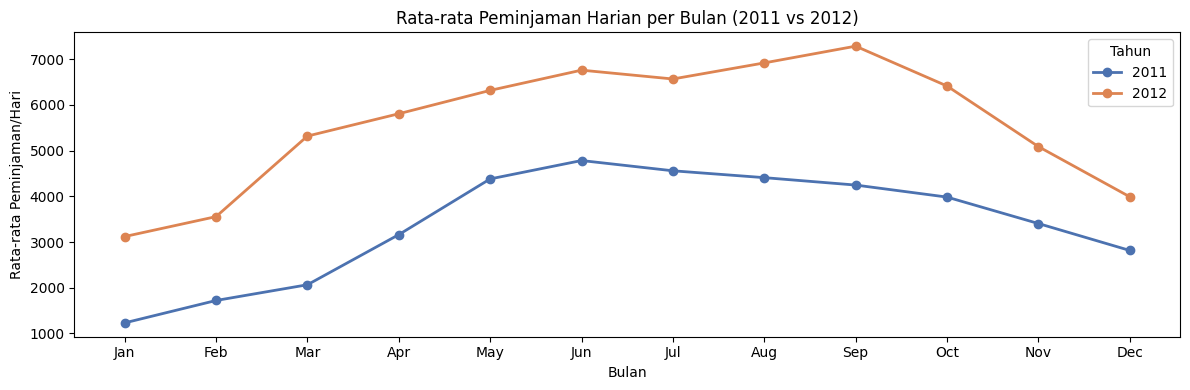

In [61]:
# Rata-rata per bulan per tahun
monthly_yr = df_day.groupby(['yr', 'mnth'], observed=True)['cnt'].mean().reset_index()
monthly_yr['mnth'] = monthly_yr['mnth'].astype(int)
monthly_yr = monthly_yr.sort_values(['yr', 'mnth'])

bulan = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12, 4))
for yr, color in zip(['2011', '2012'], ['#4C72B0', '#DD8452']):
    subset = monthly_yr[monthly_yr['yr'] == yr]
    plt.plot(subset['mnth'], subset['cnt'], marker='o', label=yr,
             color=color, linewidth=2)
plt.xticks(range(1, 13), bulan)
plt.title('Rata-rata Peminjaman Harian per Bulan (2011 vs 2012)')
plt.xlabel('Bulan')
plt.ylabel('Rata-rata Peminjaman/Hari')
plt.legend(title='Tahun')
plt.tight_layout()
plt.show()

### Pertanyaan 2: Pola per Jam dan Hari

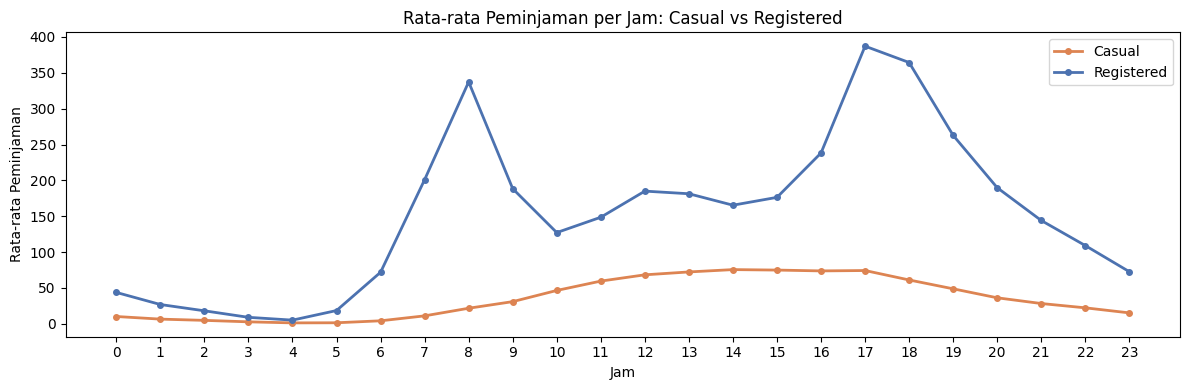

In [62]:
# Casual vs registered per jam
hourly_seg = df_hour.groupby('hr', observed=True)[['casual', 'registered']].mean().reset_index()

plt.figure(figsize=(12, 4))
plt.plot(hourly_seg['hr'], hourly_seg['casual'],     marker='o', markersize=4,
         label='Casual',     color='#DD8452', linewidth=2)
plt.plot(hourly_seg['hr'], hourly_seg['registered'], marker='o', markersize=4,
         label='Registered', color='#4C72B0', linewidth=2)
plt.xticks(range(0, 24))
plt.title('Rata-rata Peminjaman per Jam: Casual vs Registered')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Peminjaman')
plt.legend()
plt.tight_layout()
plt.show()

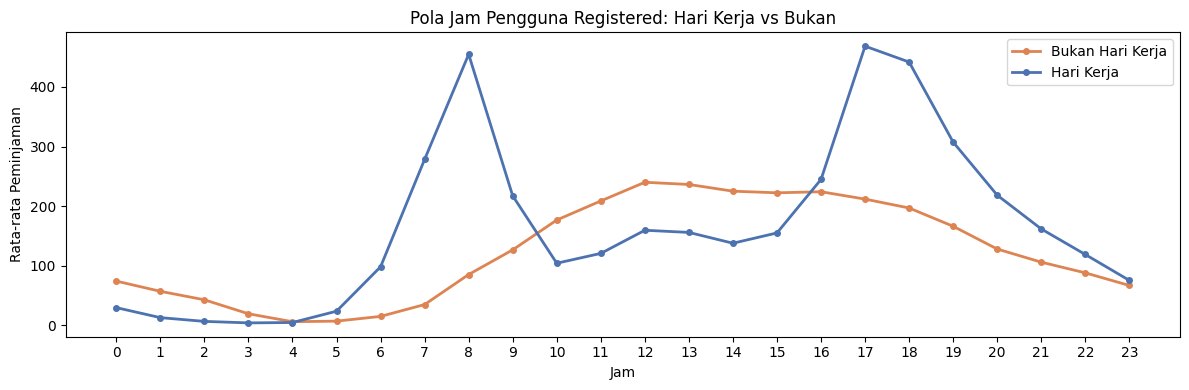

In [63]:
# Registered per jam: hari kerja vs bukan
hourly_wd = df_hour.groupby(['hr', 'workingday'], observed=True)['registered'].mean().reset_index()

plt.figure(figsize=(12, 4))
for wd, color, label in zip(['No', 'Yes'], ['#DD8452', '#4C72B0'],
                             ['Bukan Hari Kerja', 'Hari Kerja']):
    subset = hourly_wd[hourly_wd['workingday'] == wd]
    plt.plot(subset['hr'], subset['registered'], marker='o', markersize=4,
             label=label, color=color, linewidth=2)
plt.xticks(range(0, 24))
plt.title('Pola Jam Pengguna Registered: Hari Kerja vs Bukan')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Peminjaman')
plt.legend()
plt.tight_layout()
plt.show()

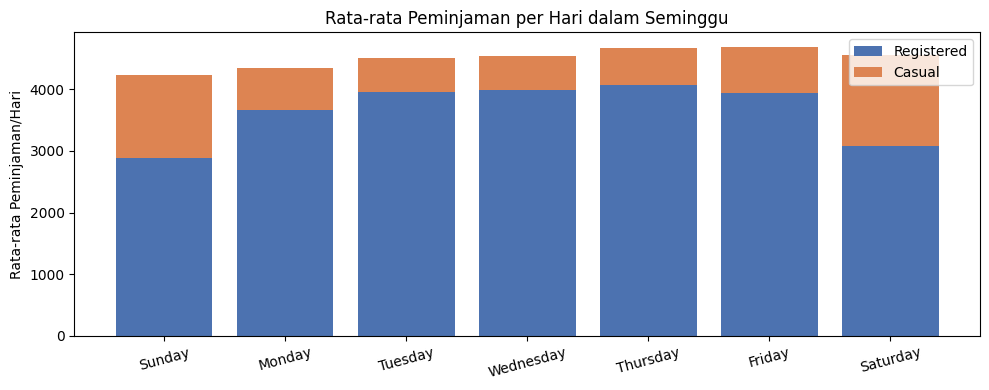

In [64]:
# Stacked bar per hari dalam seminggu
weekday_avg = df_day.groupby('weekday', observed=True)[['casual', 'registered']].mean().reset_index()

x = range(len(weekday_avg))
plt.figure(figsize=(10, 4))
plt.bar(x, weekday_avg['registered'], label='Registered', color='#4C72B0')
plt.bar(x, weekday_avg['casual'],     label='Casual',     color='#DD8452',
        bottom=weekday_avg['registered'])
plt.xticks(x, weekday_avg['weekday'], rotation=15)
plt.title('Rata-rata Peminjaman per Hari dalam Seminggu')
plt.ylabel('Rata-rata Peminjaman/Hari')
plt.legend()
plt.tight_layout()
plt.show()

### Pertanyaan 3: Pengaruh Musim dan Cuaca

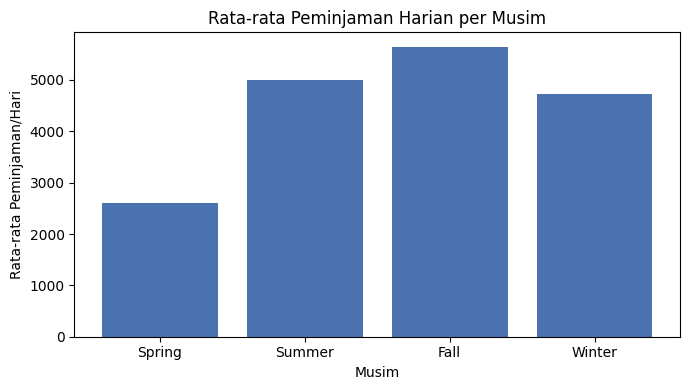

In [65]:
# Rata-rata per musim
season_avg = df_day.groupby('season', observed=True)['cnt'].mean().reset_index()

plt.figure(figsize=(7, 4))
plt.bar(season_avg['season'], season_avg['cnt'], color='#4C72B0')
plt.title('Rata-rata Peminjaman Harian per Musim')
plt.xlabel('Musim')
plt.ylabel('Rata-rata Peminjaman/Hari')
plt.tight_layout()
plt.show()

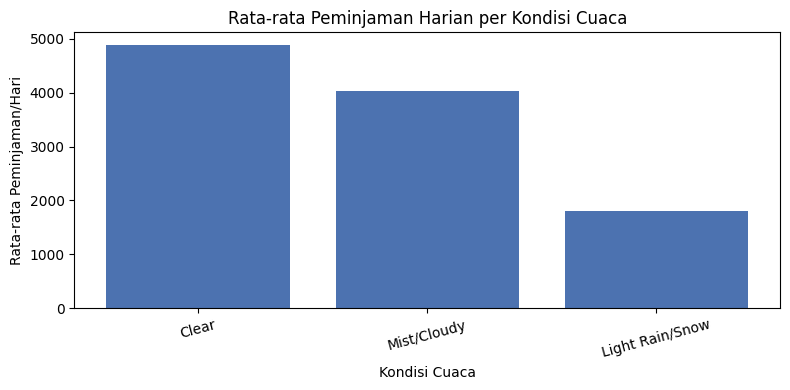

In [66]:
# Rata-rata per kondisi cuaca
weather_avg = df_day.groupby('weathersit', observed=True)['cnt'].mean().reset_index()

plt.figure(figsize=(8, 4))
plt.bar(weather_avg['weathersit'], weather_avg['cnt'], color='#4C72B0')
plt.title('Rata-rata Peminjaman Harian per Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Peminjaman/Hari')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

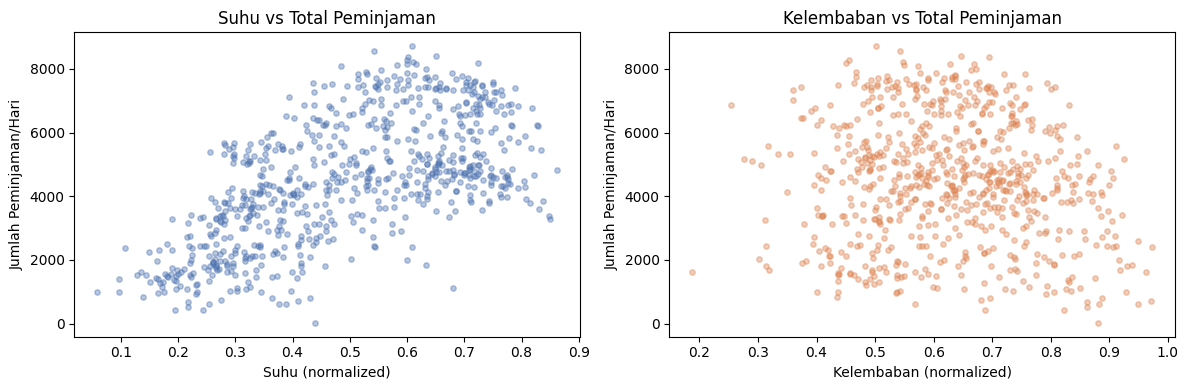

In [67]:
# Scatter suhu & kelembaban vs cnt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df_day['temp'], df_day['cnt'], alpha=0.4, color='#4C72B0', s=15)
axes[0].set_title('Suhu vs Total Peminjaman')
axes[0].set_xlabel('Suhu (normalized)')
axes[0].set_ylabel('Jumlah Peminjaman/Hari')

axes[1].scatter(df_day['hum'], df_day['cnt'], alpha=0.4, color='#DD8452', s=15)
axes[1].set_title('Kelembaban vs Total Peminjaman')
axes[1].set_xlabel('Kelembaban (normalized)')
axes[1].set_ylabel('Jumlah Peminjaman/Hari')

plt.tight_layout()
plt.show()

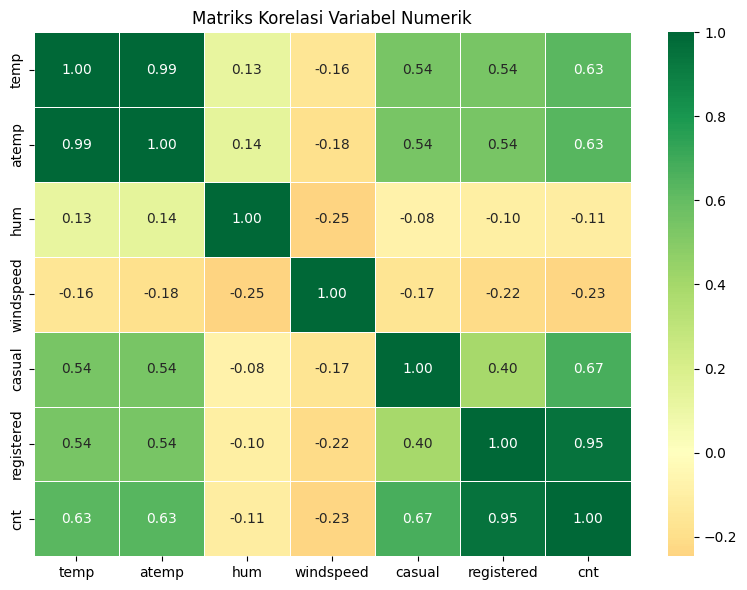

In [68]:
# Heatmap korelasi
num_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
corr = df_day[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Matriks Korelasi Variabel Numerik')
plt.tight_layout()
plt.show()

### Pertanyaan 4: Pola Hari Kerja dan Libur

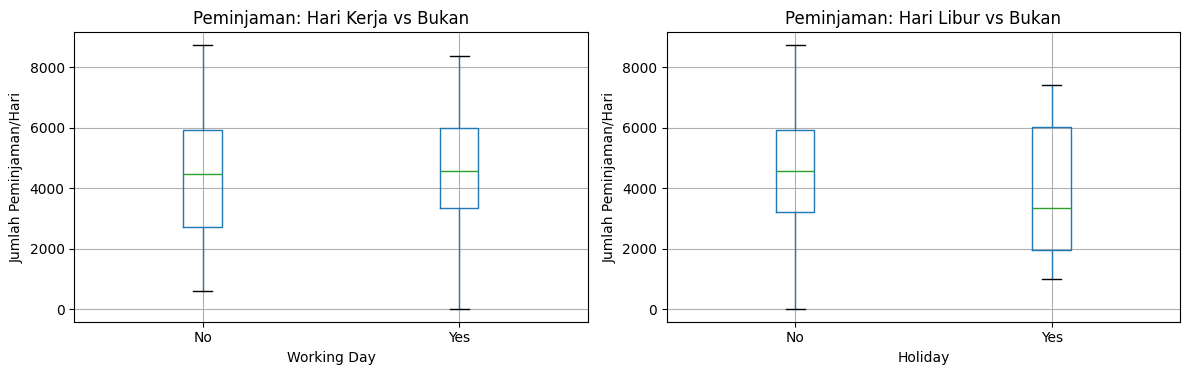

In [69]:
# Boxplot workingday & holiday
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_day.boxplot(column='cnt', by='workingday', ax=axes[0])
axes[0].set_title('Peminjaman: Hari Kerja vs Bukan')
axes[0].set_xlabel('Working Day')
axes[0].set_ylabel('Jumlah Peminjaman/Hari')

df_day.boxplot(column='cnt', by='holiday', ax=axes[1])
axes[1].set_title('Peminjaman: Hari Libur vs Bukan')
axes[1].set_xlabel('Holiday')
axes[1].set_ylabel('Jumlah Peminjaman/Hari')

plt.suptitle('')
plt.tight_layout()
plt.show()

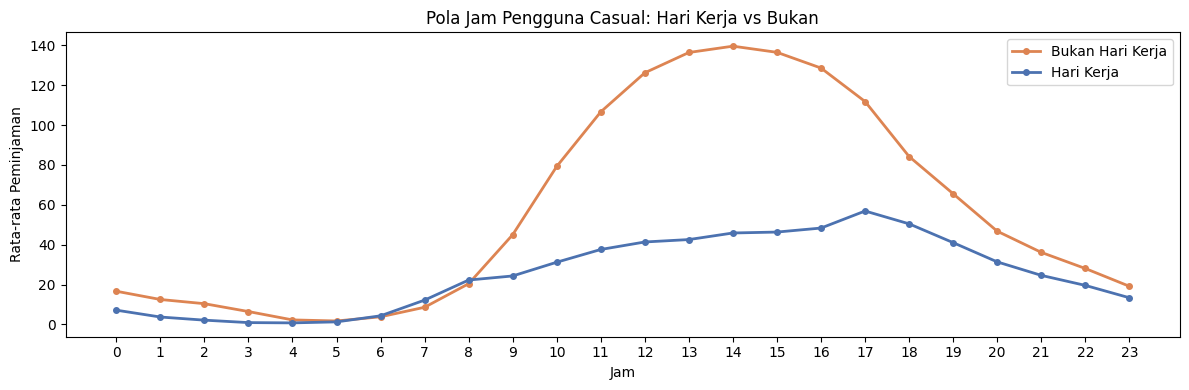

In [70]:
# Pola jam casual: hari kerja vs bukan
hourly_cas = df_hour.groupby(['hr', 'workingday'], observed=True)['casual'].mean().reset_index()

plt.figure(figsize=(12, 4))
for wd, color, label in zip(['No', 'Yes'], ['#DD8452', '#4C72B0'],
                             ['Bukan Hari Kerja', 'Hari Kerja']):
    subset = hourly_cas[hourly_cas['workingday'] == wd]
    plt.plot(subset['hr'], subset['casual'], marker='o', markersize=4,
             label=label, color=color, linewidth=2)
plt.xticks(range(0, 24))
plt.title('Pola Jam Pengguna Casual: Hari Kerja vs Bukan')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Peminjaman')
plt.legend()
plt.tight_layout()
plt.show()

### Pertanyaan 5: Segmentasi Casual dan Registered

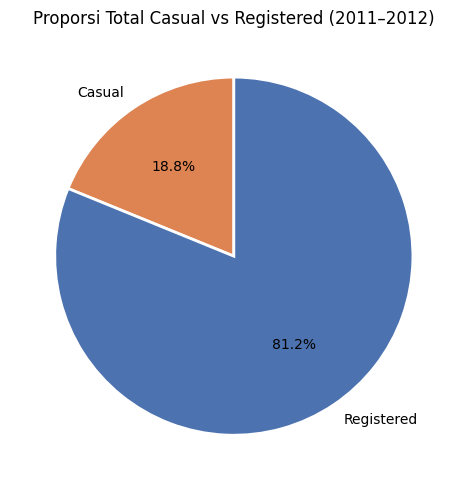

In [71]:
# Pie chart proporsi
total_casual     = df_day['casual'].sum()
total_registered = df_day['registered'].sum()

plt.figure(figsize=(5, 5))
plt.pie([total_casual, total_registered],
        labels=['Casual', 'Registered'],
        colors=['#DD8452', '#4C72B0'],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Proporsi Total Casual vs Registered (2011–2012)')
plt.tight_layout()
plt.show()

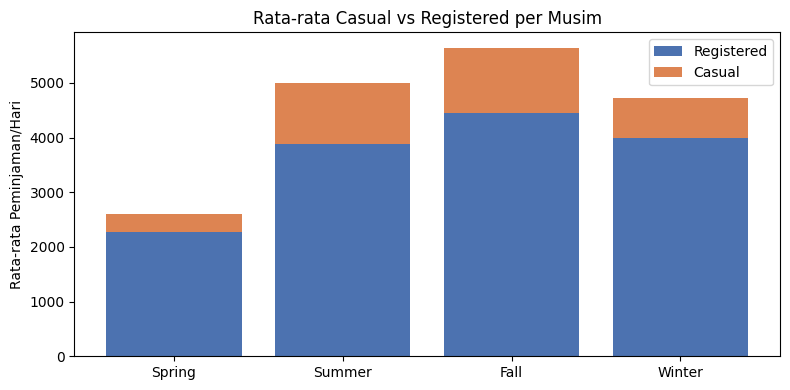

In [72]:
# Stacked bar per musim
seg_season = df_day.groupby('season', observed=True)[['casual', 'registered']].mean().reset_index()

x = range(len(seg_season))
plt.figure(figsize=(8, 4))
plt.bar(x, seg_season['registered'], label='Registered', color='#4C72B0')
plt.bar(x, seg_season['casual'],     label='Casual',     color='#DD8452',
        bottom=seg_season['registered'])
plt.xticks(x, seg_season['season'])
plt.title('Rata-rata Casual vs Registered per Musim')
plt.ylabel('Rata-rata Peminjaman/Hari')
plt.legend()
plt.tight_layout()
plt.show()

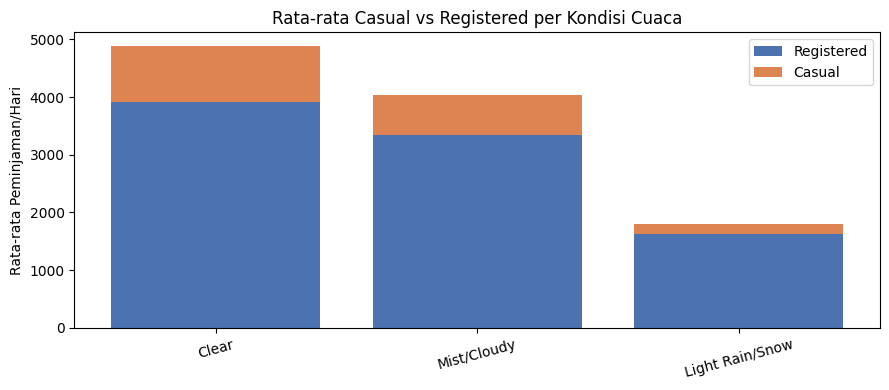

In [73]:
# Stacked bar per kondisi cuaca
seg_weather = df_day.groupby('weathersit', observed=True)[['casual', 'registered']].mean().reset_index()

x = range(len(seg_weather))
plt.figure(figsize=(9, 4))
plt.bar(x, seg_weather['registered'], label='Registered', color='#4C72B0')
plt.bar(x, seg_weather['casual'],     label='Casual',     color='#DD8452',
        bottom=seg_weather['registered'])
plt.xticks(x, seg_weather['weathersit'], rotation=15)
plt.title('Rata-rata Casual vs Registered per Kondisi Cuaca')
plt.ylabel('Rata-rata Peminjaman/Hari')
plt.legend()
plt.tight_layout()
plt.show()

**Insight:**
- Grafik tren harian memperlihatkan pola fluktuatif musiman yang berulang di kedua tahun, dengan level keseluruhan 2012 lebih tinggi dari 2011. Grafik bulanan mempertegas bahwa pertumbuhan bersifat sistemik yang tidak hanya di bulan-bulan tertentu. Ini mengindikasikan adanya pertumbuhan basis pengguna secara keseluruhan, bukan sekadar efek musiman.
- Terdapat dua karakter pengguna yang sangat berbeda. Registered membentuk dua puncak tajam di jam 8 pagi dan 17–18 sore pada hari kerja, pola yang sangat khas bagi pekerja komuter. Di weekend, pola registered berubah menjadi kurva lonceng yang menyerupai pola casual. Casual konsisten membentuk kurva lonceng dengan puncak di siang hari tanpa memandang hari kerja atau tidak.
- Bar chart per musim dan kondisi cuaca memperlihatkan penurunan peminjaman seiring memburuknya cuaca. Scatterplot suhu vs peminjaman menunjukkan tren positif yang jelas. Heatmap korelasi mengkonfirmasi bahwa temp dan atemp adalah variabel cuaca yang paling berpengaruh terhadap jumlah peminjaman.
- Boxplot memperlihatkan bahwa distribusi peminjaman di hari kerja dan weekend tumpang tindih, namun hari libur nasional memiliki distribusi yang lebih rendah dan lebih sempit. Grafik pola jam casual di hari kerja vs weekend memperlihatkan lonjakan drastis di weekend, ini mengkonfirmasi bahwa casual adalah pengguna rekreasional yang meminjam sepeda untuk memanfaatkan waktu luang.
- Pie chart memperlihatkan dominasi registered (81.2%) secara visual. Stacked bar per musim dan cuaca memperlihatkan bahwa meski registered selalu mendominasi, proporsi casual meningkat di kondisi yang lebih kondusif untuk berekreasi (musim panas, cuaca cerah). Ini menunjukkan bahwa casual sangat responsif terhadap kondisi eksternal.

## Analisis Lanjutan (Opsional)

## Conclusion & Recommendation

### Conclusion
- Sistem bike sharing mengalami pertumbuhan signifikan dari 2011 ke 2012 di semua bulan, menandakan peningkatan adopsi layanan secara keseluruhan. Permintaan bersifat musiman dengan puncak di pertengahan tahun (Jun–Sep) dan titik terendah di awal tahun (Jan–Feb).
- Terdapat dua pola penggunaan yang sangat berbeda. Pengguna registered menggunakan sepeda sebagai moda transportasi harian dengan pola komuter yang konsisten di jam sibuk pagi (08.00) dan sore (17.00–18.00) pada hari kerja. Pengguna casual menggunakan sepeda untuk rekreasi dengan pola siang hari yang lebih menonjol di weekend.
- Cuaca adalah faktor eksternal paling berpengaruh terhadap jumlah peminjaman. Suhu yang lebih hangat mendorong lebih banyak peminjaman, sedangkan kelembaban tinggi dan angin kencang berdampak negatif. Cuaca buruk dapat menurunkan peminjaman secara drastis terutama pada segmen casual.
- Total peminjaman antara hari kerja dan weekend relatif setara namun segmen penggunanya bertolak belakang. Hari libur nasional secara konsisten menghasilkan peminjaman terendah karena pengguna registered tidak beraktivitas sementara casual tidak cukup mengimbangi penurunan tersebut.
- Pengguna registered adalah tulang punggung bisnis dengan kontribusi >80% total peminjaman yang stabil di berbagai kondisi. Pengguna casual adalah segmen lebih kecil namun sangat responsif terhadap kondisi cuaca dan musim, dengan potensi konversi ke registered paling besar di musim panas dan cuaca cerah.

### Recommendation
- Menjelang musim puncak (mulai Mei), perlu dilakukan penambahan armada dan perluasan titik stasiun untuk mengantisipasi lonjakan permintaan. Di sisi lain, bulan Jan–Feb yang sepi dapat dimanfaatkan untuk menjalankan program promosi guna mendorong peminjaman di luar musim puncak, sekaligus menjadwalkan pemeliharaan armada agar tidak mengganggu operasional di musim sibuk.
- Ketersediaan sepeda perlu dipastikan di stasiun-stasiun dekat area perkantoran dan transportasi publik sebelum jam 08.00 dan sebelum jam 17.00 untuk melayani komuter registered. Untuk pengguna casual, distribusi sepeda perlu dioptimalkan ke area rekreasi dan pusat perbelanjaan pada akhir pekan. Selain itu, penerapan dynamic pricing dapat dipertimbangkan (harga lebih tinggi di jam puncak komuter dan lebih rendah di jam sepi) untuk meratakan beban operasional sekaligus meningkatkan pendapatan.
- Data prakiraan cuaca sebaiknya diintegrasikan ke dalam sistem manajemen armada agar jumlah sepeda yang disiapkan di setiap stasiun dapat disesuaikan. Pada hari dengan prakiraan cuaca buruk, biaya operasional juga dapat ditekan melalui pengurangan shift staf dan armada aktif. Untuk tetap mendorong peminjaman saat cuaca kurang ideal, program promosi seperti diskon khusus hari hujan dapat ditawarkan terutama kepada pengguna registered yang sudah loyal dengan layanan.
- Di hari libur nasional, armada dan staf operasional sebaiknya ditambah khususnya di area wisata dan rekreasi yang lebih ramai dikunjungi. Untuk meningkatkan peminjaman yang biasanya rendah di hari libur, kampanye khusus yang menargetkan pengguna casual dan wisatawan dapat dijalankan, misalnya paket tarif harian yang lebih menarik atau event komunitas bersepeda saat long weekend.
- Program loyalitas perlu menjadi prioritas utama guna meningkatkan jumlah pengguna registered. Ini dapat dilakukan melalui benefit keanggotaan seperti poin loyalitas dan diskon perpanjangan membership. Untuk pengguna casual, musim panas (Jun–Ags) adalah momentum terbaik untuk mendorong konversi ke registered karena aktivitas casual sedang berada di puncaknya. Penawaran trial membership berbiaya rendah yang dikombinasikan dengan iklan promosi dapat menjadi strategi efektif untuk memperluas basis pengguna registered.

In [74]:
df_day.to_csv("data_day.csv", index=False)
df_hour.to_csv("data_hour.csv", index=False)